#### Experiment 3a
- 1D
- Linear variation - electrode exponents vary from -1 to -2
- Adjust the frequency range of the Spectral Model (default = 2-40Hz)
- Frequency range = 2-10Hz
- 5 electrodes
- Aperiodic noise only
- Average by PSD and SpecMod. Do not produce plots, save outputs
- Load in JSON output summaries and plot a single combined plot

In [1]:
# Imports for functionality 
from dissertation_simulations.time_series import sweep_electrodes_ts_2D
from dissertation_simulations.psd import sweep_electrodes_psd_2D
from dissertation_simulations.spec_mod import sweep_electrodes_specmod_2D
from dissertation_simulations.exponents import generate_spatial_exponent_matrix, generate_2D_exponent_matrix
from dissertation_simulations.plotting import plot_summary_boxplots

import numpy as np
import json

from scipy.stats import ttest_rel

In [2]:
# Define exponent matrix
exp_matrix = generate_2D_exponent_matrix(grid_shape=(1, 5), exp_range=(-2, -1), gradient_axis="cols")
exp_matrix

array([[-2.  , -1.75, -1.5 , -1.25, -1.  ]])

{'exponent': array([[-2.  , -1.75, -1.5 , -1.25, -1.  ]]), 'fit_freq_range': [2, 10]}


C:\Users\chloe\OneDrive\Documents\Anaconda\envs\diss_worksheet\Lib\site-packages\specparam\algorithms\spectral_fit.py:497: OptimizeWarning: Covariance of the parameters could not be estimated
  pe_params, _ = curve_fit(self.modes.periodic.func,
C:\Users\chloe\OneDrive\Documents\Anaconda\envs\diss_worksheet\Lib\site-packages\specparam\algorithms\spectral_fit.py:497: OptimizeWarning: Covariance of the parameters could not be estimated
  pe_params, _ = curve_fit(self.modes.periodic.func,
C:\Users\chloe\OneDrive\Documents\Anaconda\envs\diss_worksheet\Lib\site-packages\specparam\algorithms\spectral_fit.py:497: OptimizeWarning: Covariance of the parameters could not be estimated
  pe_params, _ = curve_fit(self.modes.periodic.func,
C:\Users\chloe\OneDrive\Documents\Anaconda\envs\diss_worksheet\Lib\site-packages\specparam\algorithms\spectral_fit.py:497: OptimizeWarning: Covariance of the parameters could not be estimated
  pe_params, _ = curve_fit(self.modes.periodic.func,


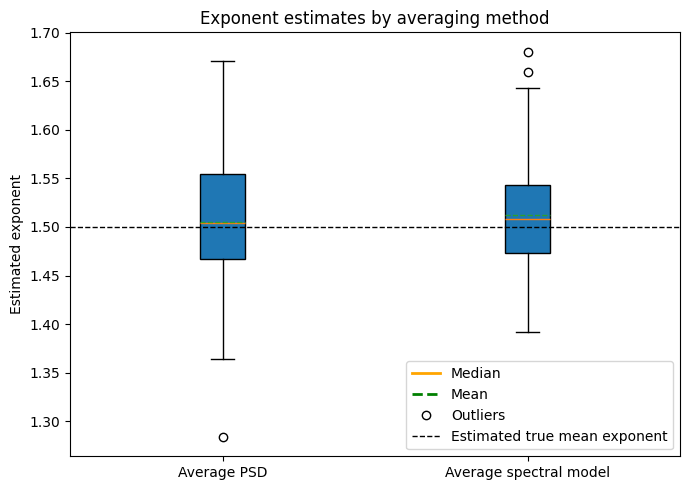

In [3]:
# Average the PSD
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D(grid_range=[(1, 5)], exponent=exp_matrix, fit_freq_range=[2, 10], 
                                                              n_repeats=100, plot=False, return_full=True)

exp3a_result1_psd = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3aresults1_psd_exp_matrix_cols_-1-2.json", "w") as f:
    json.dump(exp3a_result1_psd, f, indent=4)

# Average the SpecMod
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D(grid_range=[(1, 5)], exponent=exp_matrix, fit_freq_range=[2, 10], 
                                                              n_repeats=100, plot=False, return_full=True)

exp3a_result2_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3aresults2_specmod_exp_matrix_cols_-1-2.json", "w") as f:
    json.dump(exp3a_result2_specmod, f, indent=4)

# Loading summaries and combining into a single plot
summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3aresults1_psd_exp_matrix_cols_-1-2.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3aresults2_specmod_exp_matrix_cols_-1-2.json"
]

labels = [
    "Average PSD",
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels,
    true_mean_exp=np.mean(-exp_matrix)
)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\1D electrodes\Combined plots\exp3a_combined_plot_1D_exp_matrix_cols_-1-2.png", dpi=300, bbox_inches="tight")

In [4]:
# Paired t-tests
with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3aresults1_psd_exp_matrix_cols_-1-2.json") as f:
    psd_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3aresults2_specmod_exp_matrix_cols_-1-2.json") as f:
    spec_data = json.load(f)

psd = np.array(psd_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(psd, spec)
print(f"PSD vs Spectral model: t = {t:.3f}, p = {p:.5f}")

PSD vs Spectral model: t = -0.829, p = 0.40897


#### Experiment 3b
- 1D
- Linear variation - electrode exponents vary from -1 to -2
- Adjust the frequency range of the Spectral Model (default = 2-40Hz)
- Frequency range = 2-20Hz
- 5 electrodes
- Aperiodic noise only
- Average by PSD and SpecMod. Do not produce plots, save outputs
- Load in JSON output summaries and plot a single combined plot

{'exponent': array([[-2.  , -1.75, -1.5 , -1.25, -1.  ]]), 'fit_freq_range': [2, 20]}


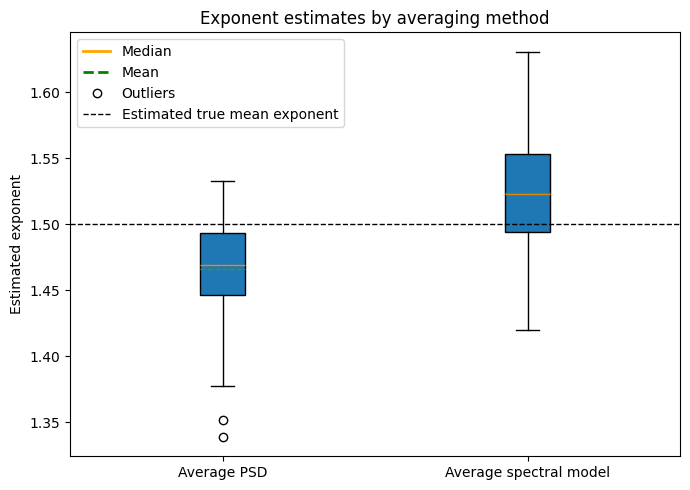

In [5]:
# Average the PSD
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D(grid_range=[(1, 5)], exponent=exp_matrix, fit_freq_range=[2, 20], 
                                                              n_repeats=100, plot=False, return_full=True)

exp3b_result1_psd = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3bresults1_psd_exp_matrix_cols_-1-2.json", "w") as f:
    json.dump(exp3b_result1_psd, f, indent=4)

# Average the SpecMod
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D(grid_range=[(1, 5)], exponent=exp_matrix, fit_freq_range=[2, 20], 
                                                              n_repeats=100, plot=False, return_full=True)

exp3b_result2_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3bresults2_specmod_exp_matrix_cols_-1-2.json", "w") as f:
    json.dump(exp3b_result2_specmod, f, indent=4)

# Loading summaries and combining into a single plot
summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3bresults1_psd_exp_matrix_cols_-1-2.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3bresults2_specmod_exp_matrix_cols_-1-2.json"
]

labels = [
    "Average PSD",
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels,
    true_mean_exp=np.mean(-exp_matrix)
)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\1D electrodes\Combined plots\exp3b_combined_plot_1D_exp_matrix_cols_-1-2.png", dpi=300, bbox_inches="tight")

In [6]:
# Paired t-tests
with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3bresults1_psd_exp_matrix_cols_-1-2.json") as f:
    psd_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3bresults2_specmod_exp_matrix_cols_-1-2.json") as f:
    spec_data = json.load(f)

psd = np.array(psd_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(psd, spec)
print(f"PSD vs Spectral model: t = {t:.3f}, p = {p:.5f}")

PSD vs Spectral model: t = -10.121, p = 0.00000


#### Experiment 3c
- 1D
- Linear variation - electrode exponents vary from -1 to -2
- Adjust the frequency range of the Spectral Model (default = 2-40Hz)
- Frequency range = 2-40Hz
- 5 electrodes
- Aperiodic noise only
- Average by PSD and SpecMod. Do not produce plots, save outputs
- Load in JSON output summaries and plot a single combined plot

{'exponent': array([[-2.  , -1.75, -1.5 , -1.25, -1.  ]]), 'fit_freq_range': [2, 40]}


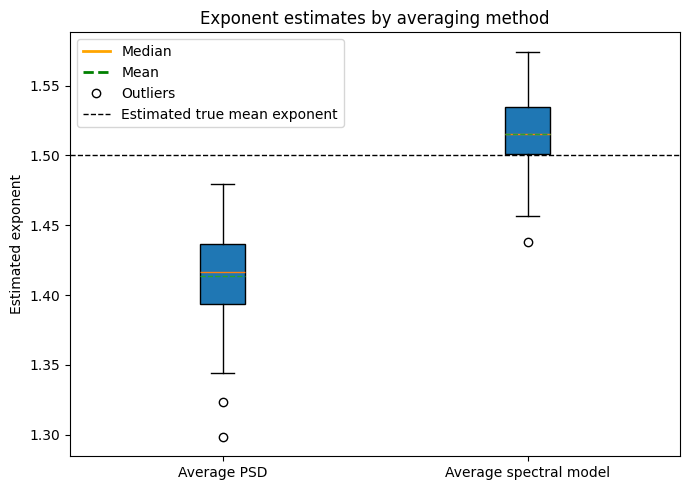

In [7]:
# Average the PSD
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D(grid_range=[(1, 5)], exponent=exp_matrix, fit_freq_range=[2, 40], 
                                                              n_repeats=100, plot=False, return_full=True)

exp3c_result1_psd = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3cresults1_psd_exp_-1-2.json", "w") as f:
    json.dump(exp3c_result1_psd, f, indent=4)

# Average the SpecMod
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D(grid_range=[(1, 5)], exponent=-1.5, fit_freq_range=[2, 40], 
                                                              n_repeats=100, plot=False, return_full=True)

exp3c_result2_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3cresults2_specmod_exp_-1-2.json", "w") as f:
    json.dump(exp3c_result2_specmod, f, indent=4)

# Loading summaries and combining into a single plot
summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3cresults1_psd_exp_-1-2.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3cresults2_specmod_exp_-1-2.json"
]

labels = [
    "Average PSD",
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels,
    true_mean_exp=np.mean(-exp_matrix)
)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\1D electrodes\Combined plots\exp3c_combined_plot_1D_exp_-1-2.png", dpi=300, bbox_inches="tight")

In [8]:
# Paired t-tests
with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3cresults1_psd_exp_-1-2.json") as f:
    psd_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3cresults2_specmod_exp_-1-2.json") as f:
    spec_data = json.load(f)

psd = np.array(psd_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(psd, spec)
print(f"PSD vs Spectral model: t = {t:.3f}, p = {p:.5f}")

PSD vs Spectral model: t = -21.765, p = 0.00000


#### Experiment 3d
- 1D
- Linear variation - electrode exponents vary from -1 to -2
- Adjust the frequency range of the Spectral Model (default = 2-40Hz)
- Frequency range = 2-80Hz
- 5 electrodes
- Aperiodic noise only
- Average by PSD and SpecMod. Do not produce plots, save outputs
- Load in JSON output summaries and plot a single combined plot

{'exponent': array([[-2.  , -1.75, -1.5 , -1.25, -1.  ]]), 'fit_freq_range': [2, 80]}


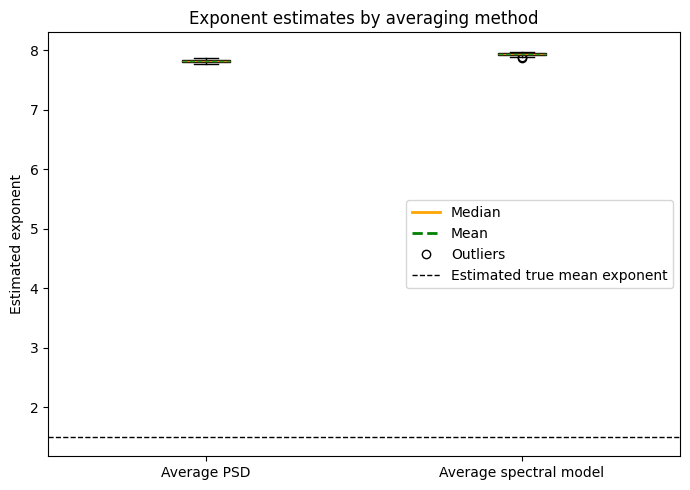

In [9]:
# Average the PSD
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D(grid_range=[(1, 5)], exponent=exp_matrix, fit_freq_range=[2, 80], 
                                                              n_repeats=100, plot=False, return_full=True)

exp3d_result1_psd = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3dresults1_psd_exp_-1-2.json", "w") as f:
    json.dump(exp3d_result1_psd, f, indent=4)

# Average the SpecMod
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D(grid_range=[(1, 5)], exponent=exp_matrix, fit_freq_range=[2, 80], 
                                                              n_repeats=100, plot=False, return_full=True)

exp3d_result2_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3dresults2_specmod_exp_-1-2.json", "w") as f:
    json.dump(exp3d_result2_specmod, f, indent=4)

# Loading summaries and combining into a single plot
summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3dresults1_psd_exp_-1-2.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3dresults2_specmod_exp_-1-2.json"
]

labels = [
    "Average PSD",
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels,
    true_mean_exp=np.mean(-exp_matrix)
)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\1D electrodes\Combined plots\exp3d_combined_plot_1D_exp_-1-2.png", dpi=300, bbox_inches="tight")

In [10]:
# Paired t-tests
with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3dresults1_psd_exp_-1-2.json") as f:
    psd_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3dresults2_specmod_exp_-1-2.json") as f:
    spec_data = json.load(f)

psd = np.array(psd_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(psd, spec)
print(f"PSD vs Spectral model: t = {t:.3f}, p = {p:.5f}")

PSD vs Spectral model: t = -39.400, p = 0.00000


#### Experiment 3e
- 1D
- Linear variation - electrode exponents vary from -1 to -2
- Adjust the frequency range of the Spectral Model (default = 2-40Hz)
- Frequency range = 2-160Hz
- 5 electrodes
- Aperiodic noise only
- Average by PSD and SpecMod. Do not produce plots, save outputs
- Load in JSON output summaries and plot a single combined plot

{'exponent': array([[-2.  , -1.75, -1.5 , -1.25, -1.  ]]), 'fit_freq_range': [2, 160]}


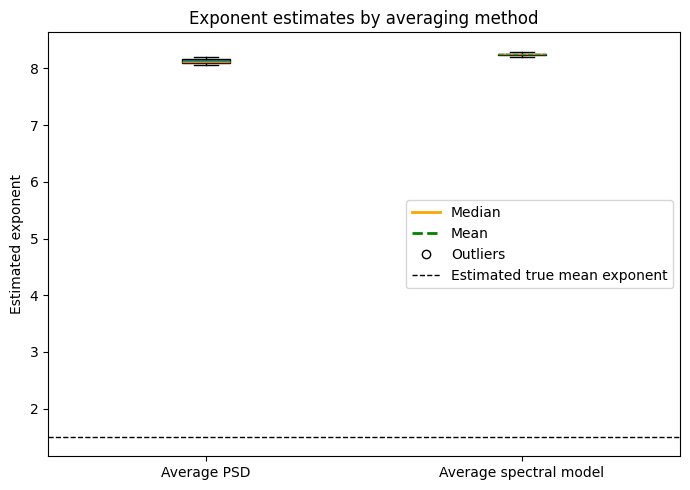

In [11]:
# Average the PSD
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D(grid_range=[(1, 5)], exponent=exp_matrix, fit_freq_range=[2, 160], 
                                                              n_repeats=100, plot=False, return_full=True)

exp3e_result1_psd = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3eresults1_psd_exp_-1-2.json", "w") as f:
    json.dump(exp3e_result1_psd, f, indent=4)

# Average the SpecMod
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D(grid_range=[(1, 5)], exponent=exp_matrix, fit_freq_range=[2, 160], 
                                                              n_repeats=100, plot=False, return_full=True)

exp3e_result2_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3eresults2_specmod_exp_-1-2.json", "w") as f:
    json.dump(exp3e_result2_specmod, f, indent=4)

# Loading summaries and combining into a single plot
summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3eresults1_psd_exp_-1-2.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3eresults2_specmod_exp_-1-2.json"
]

labels = [
    "Average PSD",
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels,
    true_mean_exp=np.mean(-exp_matrix)
)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\1D electrodes\Combined plots\exp3e_combined_plot_1D_exp_-1-2.png", dpi=300, bbox_inches="tight")

In [12]:
# Paired t-tests
with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3eresults1_psd_exp_-1-2.json") as f:
    psd_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3eresults2_specmod_exp_-1-2.json") as f:
    spec_data = json.load(f)

psd = np.array(psd_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(psd, spec)
print(f"PSD vs Spectral model: t = {t:.3f}, p = {p:.5f}")

PSD vs Spectral model: t = -30.035, p = 0.00000
